# BOTS: reproducing the experiments of Section 6 (single-file notebook)

This is a self-contained notebook that reproduces the four experiments in Section 6 of the paper *Incorporating Cognitive Biases into an Asynchronous Model of Opinion Evolution*. It needs no other files: every piece of code (simulation library, experiments, figure generation) is included in the cells below.

| Cell group | Paper section | Paper figure | What is measured |
|---|---|---|---|
| Section 6.1 | §6.1 Receptive-Resistant Region | Figure 4 | $\varepsilon$-consensus rate of two nonlinear bias functions in $\mathbf{R}$ (`conf` and `wave`) at puppet influences |
| Section 6.2 (phase) | §6.2 Malleability Region | Figure 5 | $\varepsilon$-consensus rate vs. $\eta = \max_{(i,j)}\sigma_{ji} I_{ij}$ for linear bias in $\mathbf{M}$ |
| Section 6.2 (perms) | §6.2 Malleability Region | Figure 6 | Outcomes of the 24 cyclic permutations of $\{a,b,c,d\}$ on the running graph at $\sigma\cdot I = 1.2$ |
| Section 6.3 | §6.3 Backfire Region | Figure 7 | Empirical bipartite-consensus rate and cluster imbalance distribution |

All experiments share the methodology described in the §6 "Methodology" paragraph: Erdős-Rényi influence graphs with edge probability $p = 0.4$ rejected unless strongly connected; uniform-random schedules (which are $m$-bounded fair almost surely by Property 1, satisfying the fairness hypothesis of Theorems 1, 2, and 3); run length $L_n = 200n$; $\varepsilon$-consensus when the spread stays below $\varepsilon = 10^{-3}$ for the last $10n$ actions.

## How to run this notebook

1. Open this file in Google Colab (`File → Open notebook → Upload`).
2. Pick a value for `SAMPLE_SCALE` in the **Configuration** cell.
3. Click **`Runtime → Run all`** (`Ctrl+F9` / `Cmd+F9`). Everything else is automatic.

There are no other files to upload.

## Configuration

`SAMPLE_SCALE = 1.0` reproduces the paper figures with full sample sizes (slow on free Colab). `SAMPLE_SCALE = 0.1` is a fast sanity check (~5-10 minutes total) that produces qualitatively correct figures with somewhat wider Wilson confidence intervals.

The 24-permutation sweep of Section 6.2 is exhaustive and is not affected by `SAMPLE_SCALE`.

In [5]:
# For reproduceble experiments, set pythonhashseed to a fixed value (e.g., 0)
# import os
# os.environ['PYTHONHASHSEED'] = '0'

In [6]:
# Pick one:
SAMPLE_SCALE = 0.1   
# SAMPLE_SCALE = 1.0  

import os
RESULTS_DIR = 'results'
FIGURES_DIR = 'figures'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"SAMPLE_SCALE = {SAMPLE_SCALE}")
print(f"Results will be written under  ./{RESULTS_DIR}/")
print(f"Figures will be written under  ./{FIGURES_DIR}/")

SAMPLE_SCALE = 0.1
Results will be written under  ./results/
Figures will be written under  ./figures/


## Simulation library

Implements the BOTS model of equation (2) and the bias function families of §3.1.

The asynchronous update is

$$B'[k] = \mathrm{clamp}_{[0,1]} \big( B[j] + \beta_{ji}(B[i] - B[j])\, I_{ij} \big) \quad \text{if } k = j; \quad B'[k] = B[k] \text{ otherwise.}$$

Bias function codes used by `run_bots_general`:

| code | function | parameter | region |
|---|---|---|---|
| 0 | `lin`: $\beta(x) = \sigma x$ | $\sigma$ | $\mathbf{R}$ if $0 < \sigma < 1$, $\mathbf{M}$ if $\sigma \ge 1$ |
| 1 | `conf`: $\beta(x) = x(1+\epsilon-|x|)/(1+\epsilon)$ | $\epsilon$ | $\mathbf{R}$ |
| 2 | `backf`: $\beta(x) = -x^3$ | (ignored) | $\mathbf{Bf}$ |
| 3 | `nlin`: $\beta(x) = \mu x$ with $\mu < 0$ | $\mu$ | $\mathbf{Bf}$ |
| 4 | `ins`: $\beta(x) = 0$ | (ignored) | $\mathbf{I}$ |
| 5 | `fan`: $\beta(x) = \mathrm{sign}(x)$ | (ignored) | $\mathbf{M}$ |
| 7 | `wave`: synthetic non-monotone (§6.1 footnote) | (ignored) | $\mathbf{R}$ |

In [7]:
import numpy as np
import networkx as nx


def make_strongly_connected_er(n, p, seed):
    """Generate a strongly connected Erdos-Renyi directed graph by rejection.

    The universal hypothesis of Theorems 1, 2, 3 is that G is strongly connected.
    Returns (G, edges) where edges is a list of (i, j) tuples.
    """
    rng = np.random.default_rng(seed)
    attempts = 0
    while True:
        s = int(rng.integers(0, 2**31 - 1))
        G = nx.fast_gnp_random_graph(n, p, seed=s, directed=True)
        G.remove_edges_from(nx.selfloop_edges(G))
        if nx.is_strongly_connected(G):
            return G, list(G.edges())
        attempts += 1
        if attempts > 200:
            # Deterministic fallback: add a Hamiltonian cycle
            for i in range(n):
                G.add_edge(i, (i + 1) % n)
            if nx.is_strongly_connected(G):
                return G, list(G.edges())


def run_bots_linear(edges_arr, sigma_arr, infl_arr, B0, steps, rng):
    """BOTS execution with per-edge LINEAR bias lin_{ji}(x) = sigma_{ji} x.

    Used in Section 6.2 (Figures 5 and 6). Schedule: each transition draws
    an edge uniformly at random from E (m-bounded fair almost surely by
    Property 1, so the hypothesis of Theorems 1, 2 and Corollary 1 holds).
    Returns (final state, spread history of length steps + 1).
    """
    B = B0.copy()
    spread_hist = np.empty(steps + 1)
    spread_hist[0] = B.max() - B.min()
    E = len(edges_arr)
    idx = rng.integers(0, E, size=steps)
    for t in range(steps):
        e = idx[t]
        i, j = edges_arr[e]
        x = B[i] - B[j]
        new = B[j] + sigma_arr[e] * x * infl_arr[e]
        if new < 0.0:
            new = 0.0
        elif new > 1.0:
            new = 1.0
        B[j] = new
        spread_hist[t + 1] = B.max() - B.min()
    return B, spread_hist


def run_bots_general(edges_arr, fn_codes, params, infl_arr, B0, steps, rng):
    """BOTS execution with arbitrary per-edge bias functions.

    Used in Section 6.1 (Figure 4) and Section 6.3 (Figure 7).
    fn_codes: (E,) int array of bias-function codes (see table above).
    params:   (E,) float array of per-edge parameters.
    """
    B = B0.copy()
    spread_hist = np.empty(steps + 1)
    spread_hist[0] = B.max() - B.min()
    E = len(edges_arr)
    idx = rng.integers(0, E, size=steps)
    for t in range(steps):
        e = idx[t]
        i, j = edges_arr[e]
        x = B[i] - B[j]
        c = fn_codes[e]
        p = params[e]
        if c == 0:    # lin
            beta = p * x
        elif c == 1:  # conf, eps = p
            beta = x * (1.0 + p - abs(x)) / (1.0 + p)
        elif c == 2:  # backf
            beta = -(x ** 3)
        elif c == 3:  # nlin, mu = p
            beta = p * x
        elif c == 4:  # ins
            beta = 0.0
        elif c == 5:  # fan
            beta = 0.0 if x == 0 else (1.0 if x > 0 else -1.0)
        elif c == 6:  # bounded confidence (not used in any reported figure)
            if abs(x) < p:
                beta = x * (1.01 - abs(x)) / 1.01
            else:
                beta = 0.0
        elif c == 7:  # wave (Section 6.1 footnote)
            ax = abs(x)
            if ax <= 0.02:
                beta = 0.734 * x
            elif x >= 0.02:
                beta = 0.9 * (np.sin(25 * x + np.pi) * x + x) / 2.0 + 0.01
            else:
                beta = 0.9 * (np.sin(25 * x) * x + x) / 2.0 - 0.01
        else:
            beta = 0.0
        new = B[j] + beta * infl_arr[e]
        if new < 0.0:
            new = 0.0
        elif new > 1.0:
            new = 1.0
        B[j] = new
        spread_hist[t + 1] = B.max() - B.min()
    return B, spread_hist


def epsilon_consensus(spread_hist, eps, window):
    """epsilon-consensus criterion of Section 6 (Methodology).

    True iff the spread stays below eps over the last `window` actions.
    Section 6 uses eps = 1e-3 and window = 10 n.
    """
    if len(spread_hist) < window:
        return spread_hist.max() < eps
    return spread_hist[-window:].max() < eps


def bipartite_state(B, eps):
    """Bipartite-consensus diagnostic for Section 6.3 (Figure 7).

    Definition 8: every coordinate within eps of {0, 1}, with at least one
    near 0 and at least one near 1. Returns (is_bp, frac_at_0, frac_at_1, imbalance).
    """
    near_0 = B < eps
    near_1 = B > 1.0 - eps
    if not (near_0 | near_1).all():
        return False, None, None, None
    n = len(B)
    f0 = near_0.sum() / n
    f1 = near_1.sum() / n
    imbalance = abs(f0 - f1)
    is_bp = (f0 > 0) and (f1 > 0)
    return is_bp, f0, f1, imbalance


def cluster_count(B, tol):
    """Greedy 1D cluster count used in Section 6.3 (Figure 7), tol = 0.05."""
    if len(B) == 0:
        return 0
    s = np.sort(B)
    k = 1
    last = s[0]
    for v in s[1:]:
        if v - last > tol:
            k += 1
        last = v
    return k


def wilson_ci(k, n, z=1.96):
    """Wilson 95% confidence interval for a binomial proportion k / n.

    Used for error bars on every consensus-rate plot in Section 6.
    """
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    half = (z / denom) * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return max(0.0, centre - half), min(1.0, centre + half)


def wilson_err(k, n, z=1.96):
    """Half-widths suitable for matplotlib's errorbar yerr=[err_lo, err_hi]."""
    p = k / n if n > 0 else 0.0
    lo, hi = wilson_ci(k, n, z)
    return max(0.0, p - lo), max(0.0, hi - p)


print("Simulation library loaded.")

Simulation library loaded.


## Section 6.1: Receptive-Resistant Region (Figure 4)

Theorem 1 in the paper guarantees asymptotic $\varepsilon$-consensus for every continuous bias function with graph in $\mathbf{R}$ on a strongly connected graph under $m$-bounded fairness with $m \ge |A| - 1$. This experiment measures the empirical $\varepsilon$-consensus rate under a finite simulation horizon for two specific $\mathbf{R}$ bias functions:

- **`conf`** = $x(1+\epsilon-|x|)/(1+\epsilon)$ with $\epsilon = 0.01$ (the *confirmation bias* of Alvim et al., introduced in §3.1 of the paper).
- **`wave`**: a synthetic non-monotone test function in $\mathbf{R}$ (§6.1 footnote), used to stress-test Theorem 1 on a non-monotone $\mathbf{R}$ function.

Influences are $I_{ij} = 1$ on every edge (the puppet case, the most demanding for an $\mathbf{R}$ bias). Sizes are $|A| \in \{8, 32, 128\}$. Full sample size: 25 graphs $\times$ 20 runs = 500 per cell.

In [8]:
import time, json

EPS = 1e-3
WINDOW_FACTOR = 10
RUN_FACTOR = 200
P_ER = 0.4

SIZES_61 = [8, 32, 128, 256, 512, 1024]
N_GRAPHS_61_FULL = 30
N_RUNS_61_FULL = 20
BIAS_FUNCTIONS_61 = [
    ('conf', 1, 0.01),   # confirmation bias with eps = 0.01
    ('wave', 7, 0.0),    # synthetic non-monotone test function
]


def run_section_6_1(sample_scale):
    n_graphs = max(1, int(round(N_GRAPHS_61_FULL * sample_scale)))
    n_runs = max(1, int(round(N_RUNS_61_FULL * sample_scale)))
    out = {
        'meta': {'paper_section': '6.1', 'paper_figure': 4,
                 'eps': EPS, 'window_factor': WINDOW_FACTOR,
                 'run_factor': RUN_FACTOR, 'p_er': P_ER,
                 'n_graphs': n_graphs, 'n_runs': n_runs},
        'nonlinear': {'sizes': SIZES_61, 'n_graphs': n_graphs, 'n_runs': n_runs,
                      'rates': {}, 'median_spread': {}, 'cons_count': {}},
    }
    print(f"=== Section 6.1: Receptive-Resistant Region (nonlinear bias) ===")
    print(f"    {n_graphs} graphs x {n_runs} runs = {n_graphs * n_runs} runs per cell")
    t0 = time.time()
    for fn_name, fn_code, fn_param in BIAS_FUNCTIONS_61:
        out['nonlinear']['rates'][fn_name] = []
        out['nonlinear']['median_spread'][fn_name] = []
        out['nonlinear']['cons_count'][fn_name] = []
        for n in SIZES_61:
            seed_base = abs(hash((fn_name, n))) % 10000
            cons, spreads = [], []
            for g in range(n_graphs):
                G, edges = make_strongly_connected_er(n, P_ER,
                                                     seed=seed_base * 10000 + g)
                edges_arr = np.array(edges, dtype=np.int64)
                E = len(edges)
                fn_codes_arr = np.full(E, fn_code, dtype=np.int64)
                params_arr = np.full(E, fn_param, dtype=float)
                infl_arr = np.full(E, 1.0)  # I_{ij} = 1 on every edge
                for r in range(n_runs):
                    rng = np.random.default_rng(seed_base * 10**7 + g * 10**4 + r)
                    B0 = rng.uniform(0, 1, size=n)
                    steps = RUN_FACTOR * n
                    window = WINDOW_FACTOR * n
                    _, hist = run_bots_general(edges_arr, fn_codes_arr,
                                               params_arr, infl_arr,
                                               B0, steps, rng)
                    cons.append(int(epsilon_consensus(hist, EPS, window)))
                    spreads.append(float(hist[-1]))
            cons = np.array(cons); spreads = np.array(spreads)
            rate = float(cons.mean())
            med = float(np.median(spreads))
            out['nonlinear']['rates'][fn_name].append(rate)
            out['nonlinear']['median_spread'][fn_name].append(med)
            out['nonlinear']['cons_count'][fn_name].append(
                [int(cons.sum()), int(len(cons))])
            print(f"  fn={fn_name:5s} |A|={n:3d} -> rate {rate:.3f} "
                  f"({int(cons.sum())}/{len(cons)}), "
                  f"median final spread {med:.2e}")
    print(f"Section 6.1 done in {time.time() - t0:.1f}s")
    out_path = os.path.join(RESULTS_DIR, 'results_section_6_1.json')
    with open(out_path, 'w') as f:
        json.dump(out, f, indent=2)
    print(f"Saved {out_path}")
    return out


_ = run_section_6_1(SAMPLE_SCALE)

=== Section 6.1: Receptive-Resistant Region (nonlinear bias) ===
    3 graphs x 2 runs = 6 runs per cell
  fn=conf  |A|=  8 -> rate 1.000 (6/6), median final spread 0.00e+00
  fn=conf  |A|= 32 -> rate 1.000 (6/6), median final spread 0.00e+00
  fn=conf  |A|=128 -> rate 0.833 (5/6), median final spread 1.22e-04
  fn=conf  |A|=256 -> rate 0.667 (4/6), median final spread 3.95e-04
  fn=conf  |A|=512 -> rate 0.000 (0/6), median final spread 6.41e-03
  fn=conf  |A|=1024 -> rate 0.000 (0/6), median final spread 6.57e-03
  fn=wave  |A|=  8 -> rate 1.000 (6/6), median final spread 0.00e+00
  fn=wave  |A|= 32 -> rate 1.000 (6/6), median final spread 0.00e+00
  fn=wave  |A|=128 -> rate 1.000 (6/6), median final spread 1.11e-16
  fn=wave  |A|=256 -> rate 1.000 (6/6), median final spread 1.11e-16
  fn=wave  |A|=512 -> rate 1.000 (6/6), median final spread 1.11e-16
  fn=wave  |A|=1024 -> rate 1.000 (6/6), median final spread 8.33e-17
Section 6.1 done in 50.6s
Saved results\results_section_6_1.json


## Section 6.2: Malleability Region phase diagram (Figure 5)

Corollary 1 gives the *sufficient* condition $\sigma_{ji} I_{ij} < 1$ on every edge for consensus with linear bias. This experiment maps how *conservative* that bound is by sweeping the sigma scale on Erdős-Rényi graphs and binning runs by the realised $\eta = \max_{(i,j)} \sigma_{ji} I_{ij}$.

Per-edge $\sigma_{ji} \sim \mathrm{Uniform}(0, \sigma_{\max}]$, $I_{ij} \sim \mathrm{Uniform}(0, 1]$. Sweep $\sigma_{\max} \in \{0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0\}$. Sizes $|A| \in \{8, 32, 128\}$. Full sample size: 30 graphs $\times$ 20 runs = 600 per cell, pooled across $\sigma_{\max}$ for the binning.

In [9]:
SIZES_62P = [8, 32, 128, 256, 512, 1024]
SIGMA_MAX_VALUES = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0]
N_GRAPHS_62P_FULL = 30
N_RUNS_62P_FULL = 20


def run_section_6_2_phase(sample_scale):
    n_graphs = max(1, int(round(N_GRAPHS_62P_FULL * sample_scale)))
    n_runs = max(1, int(round(N_RUNS_62P_FULL * sample_scale)))
    out_path = os.path.join(RESULTS_DIR, 'results_section_6_2_phase.json')
    out = {
        'meta': {'paper_section': '6.2', 'paper_figure': 5,
                 'eps': EPS, 'window_factor': WINDOW_FACTOR,
                 'run_factor': RUN_FACTOR, 'p_er': P_ER,
                 'n_graphs': n_graphs, 'n_runs': n_runs,
                 'sigma_max_values': SIGMA_MAX_VALUES},
        'data': {},
    }
    print(f"=== Section 6.2: Malleability Region phase diagram ===")
    print(f"    sigma_max in {SIGMA_MAX_VALUES}")
    print(f"    {n_graphs} graphs x {n_runs} runs = {n_graphs * n_runs} runs per (sigma_max, |A|) cell")
    t0 = time.time()
    for n in SIZES_62P:
        out['data'][str(n)] = []
        for sigma_max in SIGMA_MAX_VALUES:
            collected = []
            for g in range(n_graphs):
                G, edges = make_strongly_connected_er(
                    n, P_ER,
                    seed=10000 * n + 100 * g + int(100 * sigma_max))
                edges_arr = np.array(edges, dtype=np.int64)
                E = len(edges)
                graph_rng = np.random.default_rng(11111 * n + g)
                sigma_arr = graph_rng.uniform(0.01, sigma_max, size=E)
                infl_arr = graph_rng.uniform(0.05, 1.0, size=E)
                max_eff = float((sigma_arr * infl_arr).max())
                for r in range(n_runs):
                    rng = np.random.default_rng(33333 * n + 100 * g + r)
                    B0 = rng.uniform(0, 1, size=n)
                    steps = RUN_FACTOR * n
                    window = WINDOW_FACTOR * n
                    _, hist = run_bots_linear(edges_arr, sigma_arr, infl_arr,
                                              B0, steps, rng)
                    cons = int(epsilon_consensus(hist, EPS, window))
                    collected.append((max_eff, cons, float(hist[-1])))
            out['data'][str(n)].append({'sigma_max': sigma_max, 'samples': collected})
            arr = np.array(collected)
            print(f"  |A|={n:3d} sigma_max={sigma_max:.2f} "
                  f"-> rate {arr[:, 1].mean():.3f}, "
                  f"eta in [{arr[:, 0].min():.2f}, {arr[:, 0].max():.2f}], "
                  f"{len(arr)} runs")
            with open(out_path, 'w') as f:
                json.dump(out, f)  # incremental save
    print(f"Section 6.2 (phase diagram) done in {time.time() - t0:.1f}s")
    with open(out_path, 'w') as f:
        json.dump(out, f, indent=2)
    print(f"Saved {out_path}")
    return out


_ = run_section_6_2_phase(SAMPLE_SCALE)

=== Section 6.2: Malleability Region phase diagram ===
    sigma_max in [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0]
    3 graphs x 2 runs = 6 runs per (sigma_max, |A|) cell
  |A|=  8 sigma_max=0.50 -> rate 1.000, eta in [0.30, 0.42], 6 runs
  |A|=  8 sigma_max=0.80 -> rate 1.000, eta in [0.68, 0.76], 6 runs
  |A|=  8 sigma_max=1.00 -> rate 0.667, eta in [0.83, 0.88], 6 runs
  |A|=  8 sigma_max=1.20 -> rate 0.667, eta in [0.83, 0.93], 6 runs
  |A|=  8 sigma_max=1.50 -> rate 0.667, eta in [1.25, 1.32], 6 runs
  |A|=  8 sigma_max=2.00 -> rate 1.000, eta in [1.39, 1.91], 6 runs
  |A|=  8 sigma_max=3.00 -> rate 0.667, eta in [2.34, 2.73], 6 runs
  |A|= 32 sigma_max=0.50 -> rate 1.000, eta in [0.45, 0.49], 6 runs
  |A|= 32 sigma_max=0.80 -> rate 1.000, eta in [0.74, 0.76], 6 runs
  |A|= 32 sigma_max=1.00 -> rate 1.000, eta in [0.90, 0.95], 6 runs
  |A|= 32 sigma_max=1.20 -> rate 1.000, eta in [1.09, 1.17], 6 runs
  |A|= 32 sigma_max=1.50 -> rate 1.000, eta in [1.38, 1.44], 6 runs
  |A|= 32 sigma_max

## Section 6.2: 24-permutation sweep (Figure 6)

Past Corollary 1's sufficient bound, fairness alone no longer determines the outcome. This experiment exhibits that on the smallest possible example: the 3-agent running graph from Figure 1 of the paper, with $\sigma = 2.4$ and $I = 0.5$ on every edge (so the effective influence is $\sigma\cdot I = 1.2$, just past the bound), and initial state $B^0 = (0, 0.5, 1)$.

Each of the $4! = 24$ permutations of the four edges $\{a, b, c, d\}$ is run as a periodic word of length 4000. **This experiment is exhaustive and not affected by `SAMPLE_SCALE`.**

In [10]:
from itertools import permutations

LABELS_62 = ['a', 'b', 'c', 'd']
EDGES_62 = [(0, 1), (1, 2), (2, 1), (1, 0)]  # a, b, c, d
SIGMA_62 = 2.4
INFL_62 = 0.5
B_INIT_62 = np.array([0.0, 0.5, 1.0])
STEPS_62 = 4000
EPS_62 = 1e-2
WINDOW_62 = 200


def run_periodic(perm_indices):
    edges_arr = np.array(EDGES_62, dtype=np.int64)
    sigma_arr = np.full(4, SIGMA_62)
    infl_arr = np.full(4, INFL_62)
    B = B_INIT_62.copy()
    spread_hist = np.empty(STEPS_62 + 1)
    spread_hist[0] = B.max() - B.min()
    L = len(perm_indices)
    for t in range(STEPS_62):
        e = perm_indices[t % L]
        i, j = edges_arr[e]
        x = B[i] - B[j]
        new = B[j] + sigma_arr[e] * x * infl_arr[e]
        if new < 0.0:
            new = 0.0
        elif new > 1.0:
            new = 1.0
        B[j] = new
        spread_hist[t + 1] = B.max() - B.min()
    return B, spread_hist


def run_section_6_2_perm():
    out = {
        'meta': {'paper_section': '6.2', 'paper_figure': 6,
                 'sigma': SIGMA_62, 'I': INFL_62,
                 'sigma_I': SIGMA_62 * INFL_62,
                 'B_init': B_INIT_62.tolist(),
                 'eps': EPS_62, 'steps': STEPS_62,
                 'edges': EDGES_62, 'labels': LABELS_62},
        'perms': [],
    }
    perms = list(permutations(range(4)))
    print(f"=== Section 6.2: 24-permutation sweep on the running graph ===")
    print(f"    sigma = {SIGMA_62}, I = {INFL_62}, "
          f"eta = sigma * I = {SIGMA_62 * INFL_62}")
    n_converge = 0
    for p in perms:
        B_final, hist = run_periodic(list(p))
        is_cons = bool(epsilon_consensus(hist, EPS_62, WINDOW_62))
        if is_cons:
            n_converge += 1
        out['perms'].append({
            'perm': ''.join(LABELS_62[i] for i in p),
            'final_state': B_final.tolist(),
            'final_spread': float(hist[-1]),
            'consensus': is_cons,
        })
        flag = '+' if is_cons else 'x'
        print(f"  {flag} {''.join(LABELS_62[i] for i in p)}: "
              f"final={B_final.round(3).tolist()}, "
              f"spread={hist[-1]:.4f}")
    out['summary'] = {'total': len(perms), 'converged': n_converge}
    print(f"\nResult: {n_converge}/{len(perms)} permutations converge to "
          f"epsilon-consensus (eps = {EPS_62})")
    out_path = os.path.join(RESULTS_DIR, 'results_section_6_2_perm.json')
    with open(out_path, 'w') as f:
        json.dump(out, f, indent=2)
    print(f"Saved {out_path}")
    return out


_ = run_section_6_2_perm()

=== Section 6.2: 24-permutation sweep on the running graph ===
    sigma = 2.4, I = 0.5, eta = sigma * I = 1.2
  + abcd: final=[0.0, 0.0, 0.0], spread=0.0000
  + abdc: final=[0.0, 0.0, 0.0], spread=0.0000
  + acbd: final=[1.0, 1.0, 1.0], spread=0.0000
  + acdb: final=[1.0, 1.0, 1.0], spread=0.0000
  + adbc: final=[0.0, 0.0, 0.0], spread=0.0000
  x adcb: final=[0.0, 1.0, 1.0], spread=1.0000
  + bacd: final=[0.476, 0.476, 0.476], spread=0.0000
  x badc: final=[0.0, 1.0, 1.0], spread=1.0000
  + bcad: final=[0.0, 0.0, 0.0], spread=0.0000
  + bcda: final=[0.5, 0.5, 0.5], spread=0.0000
  + bdac: final=[0.357, 0.357, 0.357], spread=0.0000
  + bdca: final=[0.643, 0.643, 0.643], spread=0.0000
  + cabd: final=[0.0, 0.0, 0.0], spread=0.0000
  + cadb: final=[0.0, 0.0, 0.0], spread=0.0000
  x cbad: final=[0.0, 0.0, 1.0], spread=1.0000
  + cbda: final=[1.0, 1.0, 1.0], spread=0.0000
  + cdab: final=[1.0, 1.0, 1.0], spread=0.0000
  + cdba: final=[1.0, 1.0, 1.0], spread=0.0000
  + dabc: final=[0.5, 0.5

## Section 6.3: Backfire Region (Figure 7)

Theorem 3 says: for any continuous bias function in $\mathbf{Bf}$, every *convergent* $m$-bounded fair run with non-zero initial spread converges to a *bipartite consensus state* (Definition 8: every coordinate in $\{0, 1\}$, with at least one 0 and at least one 1). The theorem is conditional on convergence; Remark 3 conjectures convergence almost surely under uniform random scheduling.

Per-edge bias is drawn uniformly from $\{\mathrm{backf}(x) = -x^3,\ \mathrm{nlin}_{ji}(x) = \mu_{ji} x\}$ with $\mu_{ji} \sim \mathrm{Uniform}(-3, -0.1)$ (both in $\mathbf{Bf}$). Per-edge influence $I_{ij} \sim \mathrm{Uniform}(0.1, 1]$. Sizes $|A| \in \{16, 32, 64\}$. Full sample size: 50 graphs $\times$ 30 runs = 1500 per $|A|$. Bipartite tolerance $\varepsilon_{\mathbf{Bf}} = 0.01$, cluster merge tolerance $0.05$.

In [11]:
SIZES_63 = [16, 32, 64, 128, 256]
N_GRAPHS_63_FULL = 50
N_RUNS_63_FULL = 30
EPS_63 = 0.01
CLUSTER_TOL = 0.05


def run_section_6_3(sample_scale):
    n_graphs = max(1, int(round(N_GRAPHS_63_FULL * sample_scale)))
    n_runs = max(1, int(round(N_RUNS_63_FULL * sample_scale)))
    out = {
        'meta': {'paper_section': '6.3', 'paper_figure': 7,
                 'eps': EPS_63, 'window_factor': WINDOW_FACTOR,
                 'run_factor': RUN_FACTOR, 'p_er': P_ER,
                 'cluster_tol': CLUSTER_TOL,
                 'n_graphs': n_graphs, 'n_runs': n_runs},
        'data': {},
    }
    print(f"=== Section 6.3: Backfire Region (bipartite consensus) ===")
    print(f"    {n_graphs} graphs x {n_runs} runs = {n_graphs * n_runs} runs per |A|")
    t0 = time.time()
    for n in SIZES_63:
        records = []
        for g in range(n_graphs):
            G, edges = make_strongly_connected_er(
                n, P_ER, seed=20000 + 100 * g + n)
            edges_arr = np.array(edges, dtype=np.int64)
            E = len(edges)
            graph_rng = np.random.default_rng(40000 + g)
            fn_codes_arr = np.zeros(E, dtype=np.int64)
            params_arr = np.zeros(E, dtype=float)
            for e in range(E):
                if graph_rng.random() < 0.5:
                    fn_codes_arr[e] = 2          # backf
                    params_arr[e] = 0.0
                else:
                    fn_codes_arr[e] = 3          # nlin, mu ~ U(-3, -0.1)
                    params_arr[e] = graph_rng.uniform(-3.0, -0.1)
            infl_arr = graph_rng.uniform(0.1, 1.0, size=E)
            for r in range(n_runs):
                rng = np.random.default_rng(50000 + n * 1000 + g * 10 + r)
                B0 = rng.uniform(0, 1, size=n)
                steps = RUN_FACTOR * n
                B_final, hist = run_bots_general(
                    edges_arr, fn_codes_arr, params_arr, infl_arr,
                    B0, steps, rng)
                is_bp, f0, f1, imb = bipartite_state(B_final, EPS_63)
                k = cluster_count(B_final, tol=CLUSTER_TOL)
                records.append({
                    'final_spread': float(hist[-1]),
                    'is_bipartite': bool(is_bp),
                    'frac_at_0': float(f0) if f0 is not None else None,
                    'frac_at_1': float(f1) if f1 is not None else None,
                    'imbalance': float(imb) if imb is not None else None,
                    'cluster_count': int(k),
                    'consensus': bool(epsilon_consensus(
                        hist, EPS_63, WINDOW_FACTOR * n)),
                })
        out['data'][str(n)] = records
        bp_rate = np.mean([r['is_bipartite'] for r in records])
        cons_rate = np.mean([r['consensus'] for r in records])
        cluster_avg = np.mean([r['cluster_count'] for r in records])
        print(f"  |A|={n}: bipartite rate {bp_rate:.4f}, "
              f"single-value consensus rate {cons_rate:.4f}, "
              f"avg clusters {cluster_avg:.2f}, n={len(records)}")
    print(f"Section 6.3 done in {time.time() - t0:.1f}s")
    out_path = os.path.join(RESULTS_DIR, 'results_section_6_3.json')
    with open(out_path, 'w') as f:
        json.dump(out, f, indent=2)
    print(f"Saved {out_path}")
    return out


_ = run_section_6_3(SAMPLE_SCALE)

=== Section 6.3: Backfire Region (bipartite consensus) ===
    5 graphs x 3 runs = 15 runs per |A|
  |A|=16: bipartite rate 1.0000, single-value consensus rate 0.0000, avg clusters 2.00, n=15
  |A|=32: bipartite rate 1.0000, single-value consensus rate 0.0000, avg clusters 2.00, n=15
  |A|=64: bipartite rate 1.0000, single-value consensus rate 0.0000, avg clusters 2.00, n=15
  |A|=128: bipartite rate 1.0000, single-value consensus rate 0.0000, avg clusters 2.00, n=15
  |A|=256: bipartite rate 1.0000, single-value consensus rate 0.0000, avg clusters 2.00, n=15
Section 6.3 done in 15.1s
Saved results\results_section_6_3.json


## Generate Figures 4, 5, 6, 7

Each figure is built from the JSON of the corresponding experiment. Rate plots use 95% Wilson confidence intervals (matching the §6 "Methodology" paragraph). Figure 6 is exhaustive and has no error bars.

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 11,
    'legend.fontsize': 9, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'figure.dpi': 150, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'lines.linewidth': 1.5, 'lines.markersize': 5,
})


def figure_4_R_nonlinear(in_path, out_path):
    with open(in_path) as f:
        d = json.load(f)
    nl = d['nonlinear']
    sizes = nl['sizes']
    fig, ax = plt.subplots(figsize=(4.8, 3.0))
    width = 0.35
    x = np.arange(len(sizes))
    for offset, fn, color, hatch in [(-width / 2, 'conf', '#1f77b4', ''),
                                      (+width / 2, 'wave', '#ff7f0e', '//')]:
        rates = nl['rates'][fn]
        counts = nl['cons_count'][fn]
        err_lo, err_hi = [], []
        for k, n in counts:
            el, eh = wilson_err(k, n)
            err_lo.append(el); err_hi.append(eh)
        ax.bar(x + offset, rates, width, label=fr'$\mathtt{{{fn}}}$',
               color=color, edgecolor='black', linewidth=0.5, hatch=hatch)
        ax.errorbar(x + offset, rates, yerr=[err_lo, err_hi],
                    fmt='none', ecolor='black', capsize=3, linewidth=1.0)
    ax.set_xticks(x)
    ax.set_xticklabels([f'$|A|={n}$' for n in sizes])
    ax.set_ylabel(r'$\varepsilon$-consensus rate')
    ax.set_ylim(0, 1.1)
    ax.legend(loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3, axis='y')
    n_per_bar = nl['cons_count']['conf'][0][1]
    ax.set_title(f'{n_per_bar} runs per bar; bars are Wilson 95% CIs', fontsize=9)
    plt.savefig(out_path, dpi=200)
    plt.close(fig)
    print(f"Saved {out_path}  (Figure 4: Section 6.1)")


def figure_5_M_phase(in_path, out_path):
    with open(in_path) as f:
        d = json.load(f)
    fig, ax = plt.subplots(figsize=(5.0, 3.4))
    sizes = sorted(d['data'].keys(), key=int)
    markers = ['o', 's', '^', 'D', 'P', 'X']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', "#ff0d0d", "#26e0f0", "#8500e4"]
    bins = np.array([0, 0.3, 0.5, 0.7, 0.9, 1.0, 1.1, 1.3, 1.6, 2.0, 2.5, 3.0])
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    for n, m, c in zip(sizes, markers, colors):
        all_max_eff, all_cons = [], []
        for entry in d['data'][n]:
            for max_eff, cons, _ in entry['samples']:
                all_max_eff.append(max_eff); all_cons.append(cons)
        all_max_eff = np.array(all_max_eff); all_cons = np.array(all_cons)
        rates, valid_centers, err_lo, err_hi = [], [], [], []
        for k in range(len(bins) - 1):
            mask = (all_max_eff >= bins[k]) & (all_max_eff < bins[k + 1])
            if mask.sum() >= 5:
                kk = int(all_cons[mask].sum())
                nn = int(mask.sum())
                rates.append(kk / nn)
                valid_centers.append(bin_centers[k])
                el, eh = wilson_err(kk, nn)
                err_lo.append(el); err_hi.append(eh)
        ax.errorbar(valid_centers, rates, yerr=[err_lo, err_hi],
                    fmt=m + '-', color=c, label=f'$|A|={n}$',
                    capsize=2.5, linewidth=1.4, elinewidth=0.9, markersize=5)
    ax.axvline(1.0, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(1.02, 0.5, 'Corollary 1 sufficient bound',
            rotation=90, color='red', fontsize=8, va='center', alpha=0.8)
    ax.set_xlabel(r'$\max_{(i,j)\in E}\, \sigma_{ji}\, I_{ij}$ (binned)')
    ax.set_ylabel(r'$\varepsilon$-consensus rate')
    ax.set_ylim(-0.04, 1.05); ax.set_xlim(0.2, 3.05)
    ax.legend(loc='lower left', framealpha=0.9)
    ax.grid(True, alpha=0.3)
    n_graphs = d.get('meta', {}).get('n_graphs', '?')
    n_runs = d.get('meta', {}).get('n_runs', '?')
    ax.set_title(f'{n_graphs} graphs $\\times$ {n_runs} runs per cell; '
                 f'bars are Wilson 95% CIs', fontsize=9)
    plt.savefig(out_path, dpi=200)
    plt.close(fig)
    print(f"Saved {out_path}  (Figure 5: Section 6.2 phase diagram)")


def figure_6_perm_sweep(in_path, out_path):
    with open(in_path) as f:
        d = json.load(f)
    fig, ax = plt.subplots(figsize=(7.0, 2.8))
    perms = d['perms']
    labels = [p['perm'] for p in perms]
    colors = ['#2ca02c' if p['consensus'] else '#d62728' for p in perms]
    x = np.arange(len(perms))
    for i, p in enumerate(perms):
        ax.bar(i, 1.0, color=colors[i], edgecolor='black', linewidth=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=60, fontsize=7)
    ax.set_ylabel('outcome'); ax.set_yticks([]); ax.set_ylim(0, 1.1)
    sigma_I = d['meta']['sigma_I']
    summary = d['summary']
    ax.set_title(rf'24 cyclic permutations of $\{{a,b,c,d\}}$ '
                 rf'at $\sigma\cdot I = {sigma_I:.1f}$ '
                 rf'({summary["converged"]}/{summary["total"]} converge)')
    from matplotlib.patches import Patch
    handles = [
        Patch(facecolor='#2ca02c', edgecolor='black',
              label=f'converged ({summary["converged"]})'),
        Patch(facecolor='#d62728', edgecolor='black',
              label=f'did not converge ({summary["total"] - summary["converged"]})'),
    ]
    ax.legend(handles=handles, loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close(fig)
    print(f"Saved {out_path}  (Figure 6: Section 6.2 permutation sweep)")


def figure_7_Bf_bipartite(in_path, out_path):
    with open(in_path) as f:
        d = json.load(f)
    fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.0))
    sizes = sorted(d['data'].keys(), key=int)
    bp_rates, bp_err_lo, bp_err_hi = [], [], []
    cons_rates, cons_err_lo, cons_err_hi = [], [], []
    n_per_size = []
    for n in sizes:
        rs = d['data'][n]
        bp_k = sum(int(r['is_bipartite']) for r in rs)
        cons_k = sum(int(r['consensus']) for r in rs)
        nn = len(rs); n_per_size.append(nn)
        bp_rates.append(bp_k / nn); cons_rates.append(cons_k / nn)
        for arr_lo, arr_hi, k in [(bp_err_lo, bp_err_hi, bp_k),
                                   (cons_err_lo, cons_err_hi, cons_k)]:
            el, eh = wilson_err(k, nn)
            arr_lo.append(el); arr_hi.append(eh)
    ax = axes[0]
    x = np.arange(len(sizes)); width = 0.4
    ax.bar(x - width / 2, bp_rates, width, label='bipartite consensus',
           color='#d62728', edgecolor='black', linewidth=0.5)
    ax.errorbar(x - width / 2, bp_rates, yerr=[bp_err_lo, bp_err_hi],
                fmt='none', ecolor='black', capsize=3, linewidth=1.0)
    ax.bar(x + width / 2, cons_rates, width, label='single-value consensus',
           color='#2ca02c', edgecolor='black', linewidth=0.5)
    ax.errorbar(x + width / 2, cons_rates, yerr=[cons_err_lo, cons_err_hi],
                fmt='none', ecolor='black', capsize=3, linewidth=1.0)
    ax.set_xticks(x)
    ax.set_xticklabels([f'$|A|={n}$' for n in sizes])
    ax.set_ylabel('rate'); ax.set_ylim(0, 1.05)
    ax.legend(loc='center right', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_title(f'Bipartite vs single-value '
                 f'({n_per_size[0]} runs/size)', fontsize=9)
    n_target = '32' if '32' in sizes else sizes[len(sizes) // 2]
    imbalances = [r['imbalance'] for r in d['data'][n_target]
                  if r['imbalance'] is not None]
    ax = axes[1]
    ax.hist(imbalances, bins=20, color='#9467bd',
            edgecolor='black', linewidth=0.5)
    ax.set_xlabel(r'cluster imbalance $\,||C_0|-|C_1||\,/\,|A|$')
    ax.set_ylabel('count')
    ax.set_title(f'cluster imbalance, $|A|={n_target}$', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close(fig)
    print(f"Saved {out_path}  (Figure 7: Section 6.3)")


# Build all four figures
figure_4_R_nonlinear(
    os.path.join(RESULTS_DIR, 'results_section_6_1.json'),
    os.path.join(FIGURES_DIR, 'figure_4_section_6_1.png'))
figure_5_M_phase(
    os.path.join(RESULTS_DIR, 'results_section_6_2_phase.json'),
    os.path.join(FIGURES_DIR, 'figure_5_section_6_2_phase.png'))
figure_6_perm_sweep(
    os.path.join(RESULTS_DIR, 'results_section_6_2_perm.json'),
    os.path.join(FIGURES_DIR, 'figure_6_section_6_2_perm.png'))
figure_7_Bf_bipartite(
    os.path.join(RESULTS_DIR, 'results_section_6_3.json'),
    os.path.join(FIGURES_DIR, 'figure_7_section_6_3.png'))
print("\nFigure generation complete.")

Saved figures\figure_4_section_6_1.png  (Figure 4: Section 6.1)
[0.41855606 0.41855606 0.30356753 0.30356753 0.32870703 0.32870703
 0.76076096 0.76076096 0.6812217  0.6812217  0.68911327 0.68911327
 0.82910066 0.82910066 0.88419955 0.88419955 0.85560145 0.85560145
 0.92956455 0.92956455 0.83254883 0.83254883 0.91972182 0.91972182
 1.25325592 1.25325592 1.32280819 1.32280819 1.24513233 1.24513233
 1.51507157 1.51507157 1.38750319 1.38750319 1.91456715 1.91456715
 2.72725017 2.72725017 2.33666973 2.33666973 2.43376656 2.43376656]
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False]
[ True  True  True  True  True  True False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False Fa

## Display Figures 4-7 inline

### Figure 4 (Section 6.1): Nonlinear R bias

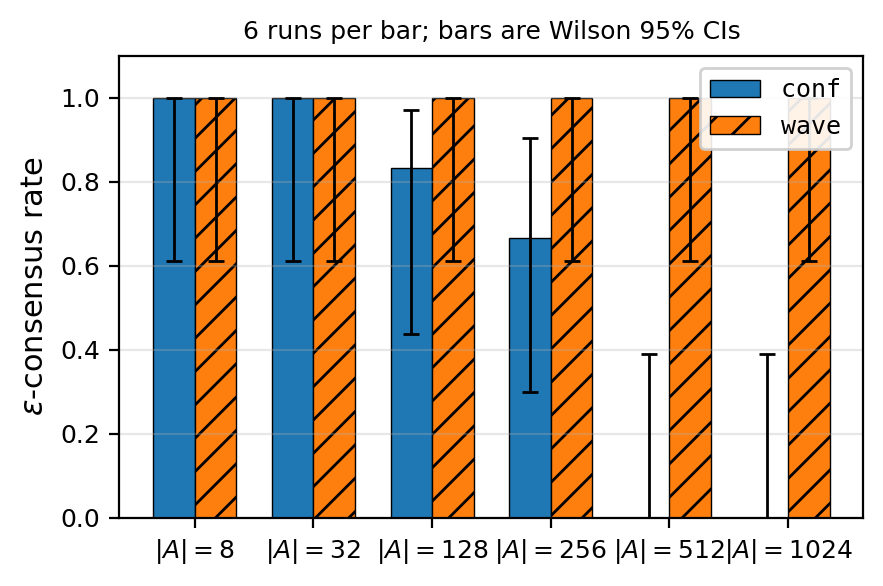

### Figure 5 (Section 6.2): M-region phase diagram

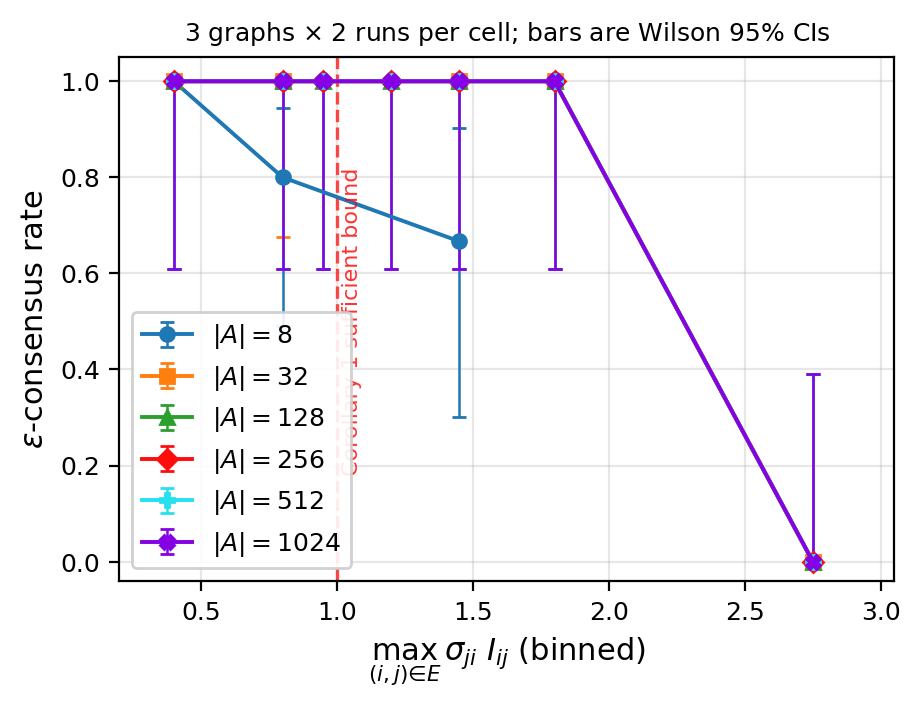

### Figure 6 (Section 6.2): 24-permutation sweep

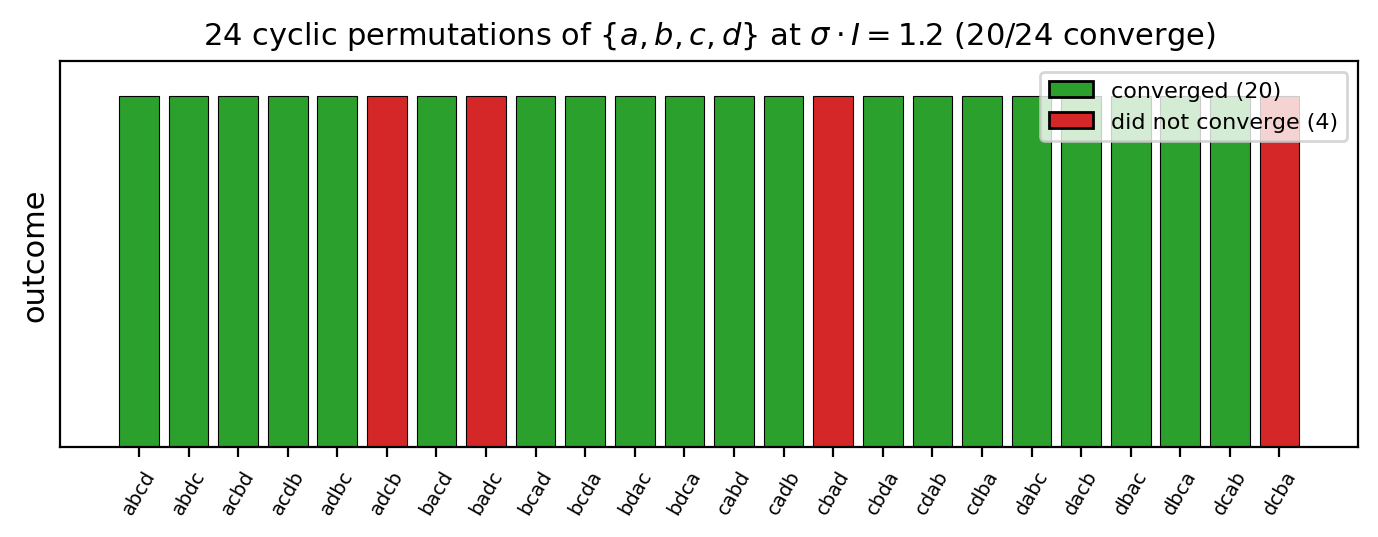

### Figure 7 (Section 6.3): Backfire region

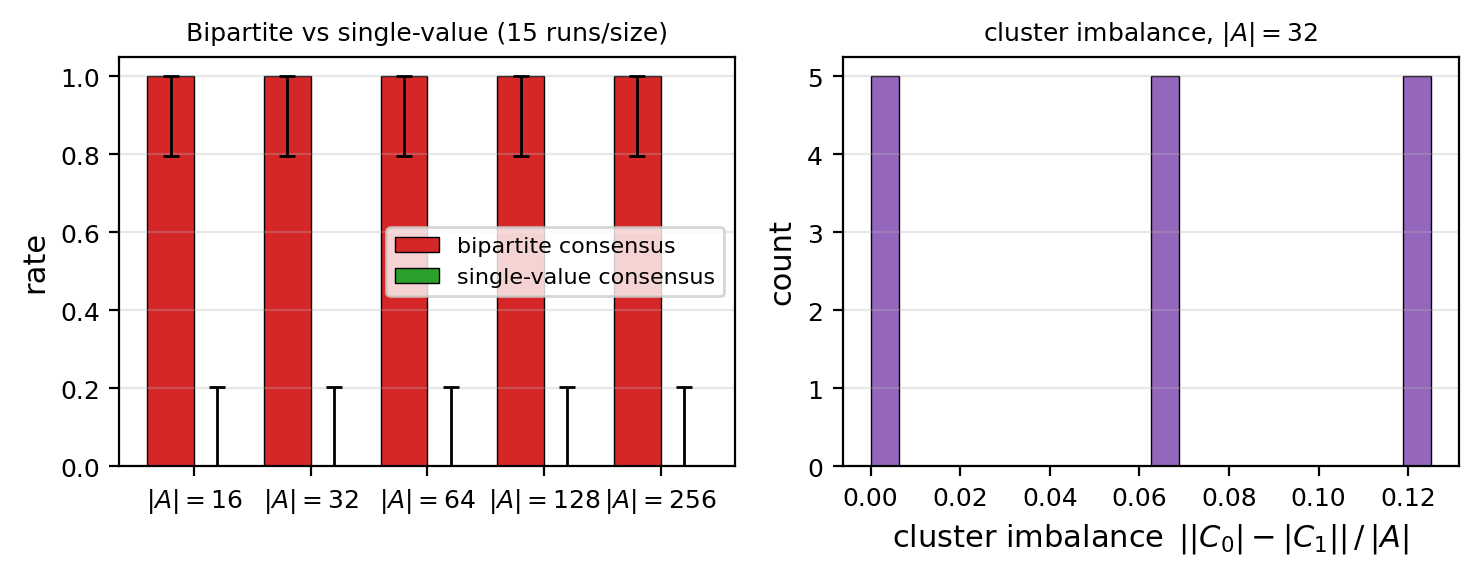

In [13]:
from IPython.display import Image, display, Markdown

for fname, title in [
    ('figure_4_section_6_1.png',          'Figure 4 (Section 6.1): Nonlinear R bias'),
    ('figure_5_section_6_2_phase.png',    'Figure 5 (Section 6.2): M-region phase diagram'),
    ('figure_6_section_6_2_perm.png',     'Figure 6 (Section 6.2): 24-permutation sweep'),
    ('figure_7_section_6_3.png',          'Figure 7 (Section 6.3): Backfire region'),
]:
    path = os.path.join(FIGURES_DIR, fname)
    if os.path.exists(path):
        display(Markdown(f'### {title}'))
        display(Image(filename=path))
    else:
        display(Markdown(f'### {title}  *(missing)*'))

## Compare to the headline numbers reported in §6 of the paper

With `SAMPLE_SCALE = 1.0` the empirical numbers should match closely. With `SAMPLE_SCALE = 0.1` they should agree qualitatively, with a few percent of slack on the rates.

Paper claims being checked:
- **§6.1 (Figure 4)**: `wave` reaches consensus on essentially every run; `conf` reaches consensus on every run at $|A|=8$ and on a small fraction at $|A|=128$ (paper value: 0.138).
- **§6.2 (Figure 5)**: every run with $\eta < 1$ reaches consensus; for $|A| \ge 32$ the rate stays at 1 until $\eta$ exceeds $\approx 2$.
- **§6.2 (Figure 6)**: 20/24 permutations converge.
- **§6.3 (Figure 7)**: bipartite consensus reached on $98.7\%$ to $100\%$ of runs depending on size; average cluster count $2.00$-$2.01$.

In [14]:
def safe_load(path):
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)


print('Section 6.1 (Figure 4):')
d = safe_load(os.path.join(RESULTS_DIR, 'results_section_6_1.json'))
if d is not None:
    nl = d['nonlinear']
    print(f"  conf rates by |A|={nl['sizes']}: "
          f"{[round(r, 3) for r in nl['rates']['conf']]}    "
          f"(paper: [1.000, 0.970, 0.138])")
    print(f"  wave rates by |A|={nl['sizes']}: "
          f"{[round(r, 3) for r in nl['rates']['wave']]}    "
          f"(paper: [1.000, 1.000, 1.000])")
else:
    print('  (results missing)')

print()
print('Section 6.2 phase (Figure 5):')
d = safe_load(os.path.join(RESULTS_DIR, 'results_section_6_2_phase.json'))
if d is not None:
    for n in sorted(d['data'], key=int):
        rates_by_sigma = [(e['sigma_max'],
                           np.mean([s[1] for s in e['samples']]))
                          for e in d['data'][n]]
        print(f"  |A|={n}: rates by sigma_max =",
              ', '.join(f'{s:.1f}->{r:.3f}' for s, r in rates_by_sigma))
else:
    print('  (results missing)')

print()
print('Section 6.2 permutations (Figure 6):')
d = safe_load(os.path.join(RESULTS_DIR, 'results_section_6_2_perm.json'))
if d is not None:
    print(f"  {d['summary']['converged']}/{d['summary']['total']} "
          f"permutations converge    (paper: 20/24)")
else:
    print('  (results missing)')

print()
print('Section 6.3 (Figure 7):')
d = safe_load(os.path.join(RESULTS_DIR, 'results_section_6_3.json'))
if d is not None:
    for n in sorted(d['data'], key=int):
        rs = d['data'][n]
        bp = sum(int(r['is_bipartite']) for r in rs) / len(rs)
        cl = np.mean([r['cluster_count'] for r in rs])
        print(f"  |A|={n}: bipartite rate {bp:.4f}, avg clusters {cl:.3f}    "
              f"(paper |A|=16: 0.987, 32: 0.999, 64: 1.000; clusters 2.00-2.01)")
else:
    print('  (results missing)')

Section 6.1 (Figure 4):
  conf rates by |A|=[8, 32, 128, 256, 512, 1024]: [1.0, 1.0, 0.833, 0.667, 0.0, 0.0]    (paper: [1.000, 0.970, 0.138])
  wave rates by |A|=[8, 32, 128, 256, 512, 1024]: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]    (paper: [1.000, 1.000, 1.000])

Section 6.2 phase (Figure 5):
  |A|=8: rates by sigma_max = 0.5->1.000, 0.8->1.000, 1.0->0.667, 1.2->0.667, 1.5->0.667, 2.0->1.000, 3.0->0.667
  |A|=32: rates by sigma_max = 0.5->1.000, 0.8->1.000, 1.0->1.000, 1.2->1.000, 1.5->1.000, 2.0->1.000, 3.0->0.000
  |A|=128: rates by sigma_max = 0.5->1.000, 0.8->1.000, 1.0->1.000, 1.2->1.000, 1.5->1.000, 2.0->1.000, 3.0->0.000
  |A|=256: rates by sigma_max = 0.5->1.000, 0.8->1.000, 1.0->1.000, 1.2->1.000, 1.5->1.000, 2.0->1.000, 3.0->0.000
  |A|=512: rates by sigma_max = 0.5->1.000, 0.8->1.000, 1.0->1.000, 1.2->1.000, 1.5->1.000, 2.0->1.000, 3.0->0.000
  |A|=1024: rates by sigma_max = 0.5->1.000, 0.8->1.000, 1.0->1.000, 1.2->1.000, 1.5->1.000, 2.0->1.000, 3.0->0.000

Section 6.2 permutatio

## (Optional) Download all results as a zip

Wraps `results/` and `figures/` into zips so you can right-click them in the Files panel and download.

In [15]:
import shutil
shutil.make_archive('bots_results', 'zip', '.', 'results')
shutil.make_archive('bots_figures', 'zip', '.', 'figures')
print('Wrote bots_results.zip and bots_figures.zip in', os.getcwd())

Wrote bots_results.zip and bots_figures.zip in c:\Users\mauricio.munoz\Desktop\Univalle\TrabajoGrado\Paper\COORDINATION\Code
